# Module 3 - Driver Ratings Regression

## Goal
Predict numeric/rounded driver ratings from telematics features. 
Emphasize explainability.

## Dataset Used
- **telemetry_samples.csv** → 1,000 records with telematics features and ratings

## Approach
1. Train/test split (stratified by rating)
2. Baseline model → Linear Regression
3. Stronger model → RandomForest or XGBoost
4. Evaluate using RMSE and MAE
5. Explainability using SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', 50)
%matplotlib inline

In [2]:
telem = pd.read_csv("../data/telemetry_samples.csv")

print(f"Shape: {telem.shape}")
print(telem.columns.tolist())
telem.head()

Shape: (1000, 19)
['ip_id', 'driver_id', 'trip_id', 'timestamp', 'speed', 'throttle', 'brake', 'steering_angle', 'gps_lat', 'gps_lon', 'accel_x', 'accel_y', 'accel_z', 'event_code', 'hard_brake', 'trip_duration_sec', 'distance_km', 'rating', 'complaints_count']


,ip_id,driver_id,trip_id,timestamp,speed,throttle,brake,steering_angle,gps_lat,gps_lon,accel_x,accel_y,accel_z,event_code,hard_brake,trip_duration_sec,distance_km,rating,complaints_count
0,IP0000,D031,T0000,2024-01-01 00:00:00,53.17,0.71,0.06,-9.63,14.065671,120.918158,0.278,-0.649,10.035,normal,0,6843,101.06,4,0
1,IP0001,D002,T0001,2024-01-01 00:30:00,21.21,0.43,0.15,41.56,14.739013,121.622461,-0.113,-0.731,10.027,normal,0,6689,39.41,5,0
2,IP0002,D046,T0002,2024-01-01 01:00:00,3.91,0.33,0.17,-7.58,14.443732,121.735536,-0.215,0.505,9.886,normal,0,4507,4.89,5,0
3,IP0003,D034,T0003,2024-01-01 01:30:00,46.85,0.69,0.16,9.10,14.762105,121.299142,1.004,-0.757,9.902,normal,0,5589,72.74,5,0
4,IP0004,D013,T0004,2024-01-01 02:00:00,42.92,0.43,0.14,18.88,14.540666,121.347942,-0.736,0.137,9.885,normal,0,6018,71.75,5,0


In [3]:
features = ['speed', 'throttle', 'brake', 'steering_angle', 
            'accel_x', 'accel_y', 'accel_z', 'hard_brake', 
            'trip_duration_sec', 'distance_km', 'complaints_count']

X = telem[features]
y = telem['rating']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nRating distribution:")
print(y.value_counts().sort_index())

Features shape: (1000, 11)
Target shape: (1000,)

Rating distribution:
rating
2     13
3    131
4    562
5    294
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining rating distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest rating distribution:")
print(y_test.value_counts().sort_index())

Training set: (800, 11)
Test set: (200, 11)

Training rating distribution:
rating
2     10
3    105
4    450
5    235
Name: count, dtype: int64

Test rating distribution:
rating
2      3
3     26
4    112
5     59
Name: count, dtype: int64


In [5]:
# Baseline - Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

Linear Regression Results:
RMSE: 0.5732
MAE: 0.4556


# Visualizing the predictions vs actual

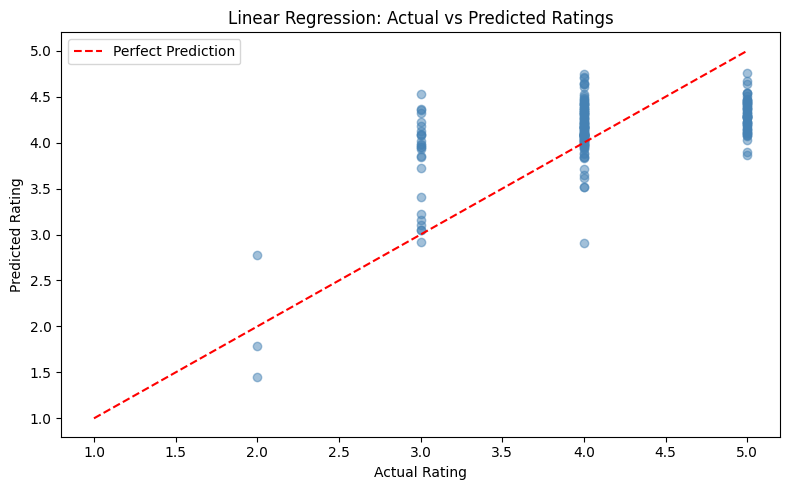

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([1, 5], [1, 5], 'r--', label='Perfect Prediction')
plt.title('Linear Regression: Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot above represents the actual ratings against the predicted ratings from our Linear Regression Baseline Model. The dashed red line represents perfect predictions. The performance of the model is such that it gives an RMSE of 0.5732 and an MAE of 0.4556. This means that the predictions are on average within half a star of the actual ratings. The performance of the model is best when the actual rating is 4 because it is the most common class. However, the performance of the model is poor when the actual rating is 2 because of class imbalance. This will be compared with a better RandomForest or XGBoost model.

## Random Forest Model

In [7]:
# this will be our Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [8]:
# This will be served as the predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"RandomForest Results:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")

RandomForest Results:
RMSE: 0.5733
MAE: 0.4641


## Comparing the Linear Regression and Random Forest Models

In [9]:
print(f"Model Comparison:")
print(f"{'Model':<20} {'RMSE':<10} {'MAE':<10}")
print(f"{'-'*40}")
print(f"{'Linear Regression Model':<20} {rmse:<10.4f} {mae:<10.4f}")
print(f"{'Random Forest Model':<20} {rmse_rf:<10.4f} {mae_rf:<10.4f}")

Model Comparison:
Model                RMSE       MAE       
----------------------------------------
Linear Regression Model 0.5732     0.4556    
Random Forest Model  0.5733     0.4641    


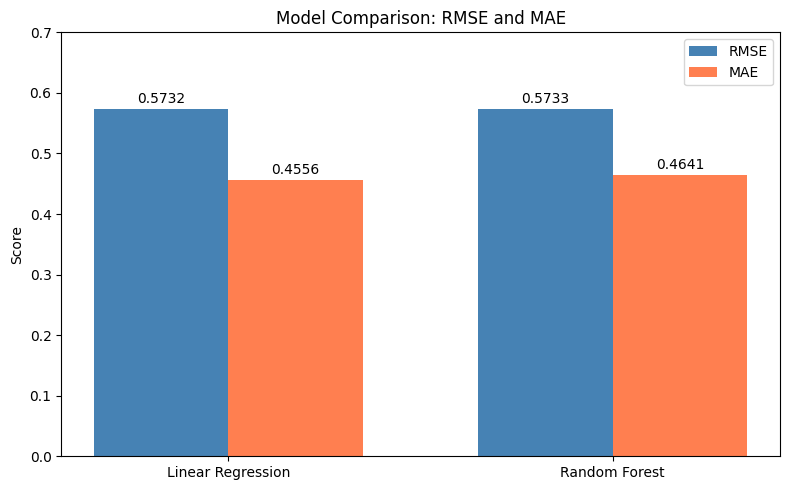

In [10]:
# Visualize comparison
models = ['Linear Regression', 'Random Forest']
rmse_scores = [0.5732, 0.5733]
mae_scores = [0.4556, 0.4641]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, rmse_scores, width, label='RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, mae_scores, width, label='MAE', color='coral')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Model Comparison: RMSE and MAE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0, 0.7)
ax.legend()
plt.tight_layout()
plt.show()

The bar chart compares 2 of the models being trained in terms of RMSE and MAE. As seen in the chart, Linear Regression Reaches 0.5732 and 0.4556, while the Random Forest Reached 0.5733 and 0.4641. They're close, but Linear regression leads this slightly. This made sense since we did have a synthetic dataset, and the dataset isn't as complex enough.

# SHAP

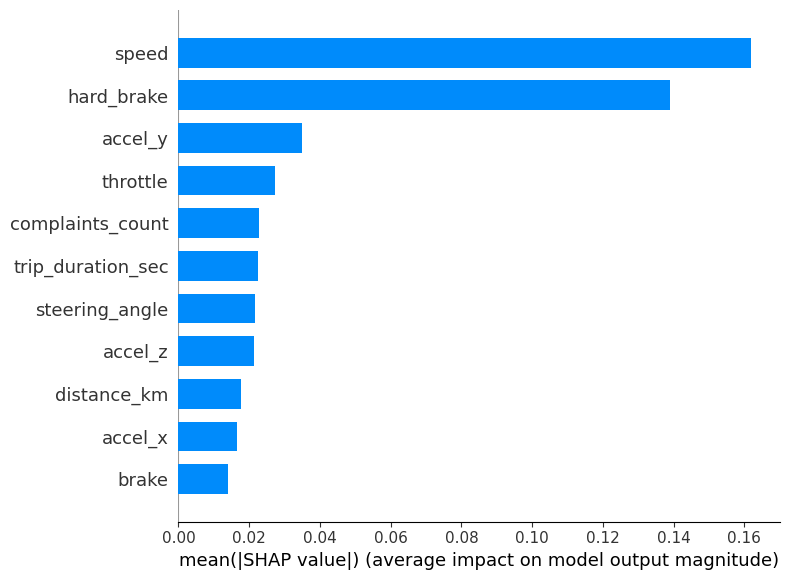

In [11]:
# SHAP explainability for RandomForest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

The SHAP bar chart also indicates that the features that contribute the most to the model’s prediction of driver ratings are mostly related to speed and hard braking. This makes sense, as this type of aggressive driving is likely to directly impact the ride that passengers have and therefore directly affect driver ratings. On the other hand, features such as brake and accel_x contribute the least to the model’s output.

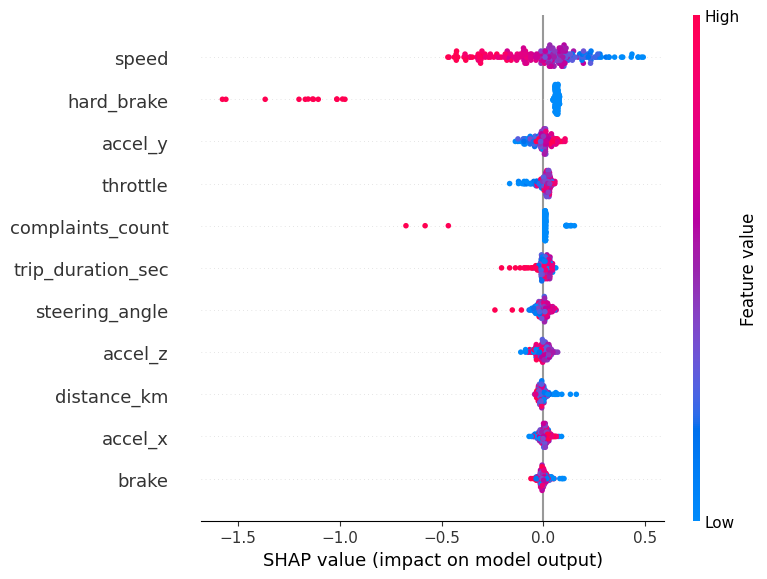

In [12]:
# Dot Plots
shap.summary_plot(shap_values, X_test)

The SHAP dot plot not only shows what features are most important to the model but also shows the direction of the features. This means that the pink or red dots indicate high values of the features, while the blue dots indicate low values. From the above plot, it can be observed that the higher speed tends to increase the rating. On the other hand, the pink dots on the left side of the plot, which indicate hard braking events, decrease the rating considerably. The number of complaints also behaves similarly. The other features are around zero, meaning they have little to no directional impact on the rating.